# Probe Feasibility — MountainCar Safe-RL

**Pertanyaan:** apakah ada trajektori yang bisa sampai goal **sambil** menjaga total cost (hukuman ngebut) di bawah limit 15?

Ini **bukan training**. Kita salin rumus fisika MountainCar (persis konstanta gymnasium), lalu jalankan pengendali tulisan tangan untuk mengukur cost dari trajektori yang berhasil solve. Tujuannya menjawab "tembok atau bukan" dengan murah.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Konstanta dinamika & aturan cost

Dinamika identik dengan `MountainCar-v0`. Aturan cost diambil dari `src/envs.py` (`ConstrainedMountainCar`): tiap langkah, kalau `|v| > 0.04`, cost `= (|v| - 0.04) * 100`; selain itu 0.

In [4]:
# Dinamika MountainCar-v0 (identik gymnasium)
FORCE   = 0.001
GRAVITY = 0.0025
MAX_SPEED = 0.07
MIN_POS, MAX_POS = -1.2, 0.6
GOAL = 0.5
MAX_EP_LEN = 200

# Aturan cost dari ConstrainedMountainCar
SPEED_THRESH = 0.04
COST_LIMIT   = 15.0

## 2. Fisika satu langkah, cost, dan satu episode

In [5]:
def step(pos, vel, action):
    # action: 0 = dorong kiri, 1 = diam, 2 = dorong kanan
    vel += (action - 1) * FORCE + np.cos(3 * pos) * (-GRAVITY)
    vel = np.clip(vel, -MAX_SPEED, MAX_SPEED)
    pos += vel
    if pos < MIN_POS:
        pos = MIN_POS
        if vel < 0:
            vel = 0.0
    return pos, vel

def step_cost(vel):
    # definisi cost: (|v| - 0.04) * 100, hanya saat ngebut
    v = abs(vel)
    return (v - SPEED_THRESH) * 100.0 if v > SPEED_THRESH else 0.0

def run_episode(policy, start_pos, max_len=MAX_EP_LEN):
    pos, vel = start_pos, 0.0
    total_cost = 0.0
    for t in range(max_len):
        a = policy(pos, vel)
        pos, vel = step(pos, vel, a)
        total_cost += step_cost(vel)          # jumlahkan cost tiap langkah
        if pos >= GOAL:                        # sampai goal -> selesai
            return dict(solved=True, steps=t + 1, cost=total_cost)
    return dict(solved=False, steps=max_len, cost=total_cost)

## 3. Dua pengendali

- `pump` — ngebut biasa: pompa momentum terus, tanpa rem.
- `pump_capped(cap)` — "dorong tapi jangan ngebut": pompa, tapi begitu kecepatan menyentuh `cap`, lepas gas. Cap kecil = lebih hemat cost tapi lebih lambat.

In [6]:
def pump(pos, vel):
    return 2 if vel >= 0 else 0

def pump_capped(cap):
    def pol(pos, vel):
        if abs(vel) >= cap:
            return 1                            # coasting
        return 2 if vel >= 0 else 0
    return pol

## 4. Jalankan sweep atas 200 start acak

In [7]:
rng = np.random.default_rng(0)
starts = rng.uniform(-0.6, -0.4, size=200)     # sama seperti reset MountainCar

def evaluate(policy):
    res = [run_episode(policy, s) for s in starts]
    solved = [r for r in res if r['solved']]
    costs  = np.array([r['cost']  for r in solved]) if solved else np.array([])
    steps  = np.array([r['steps'] for r in solved]) if solved else np.array([])
    return dict(rate=len(solved)/len(res), costs=costs, steps=steps)

caps = [0.070, 0.060, 0.055, 0.050, 0.045, 0.043, 0.042, 0.041, 0.040]
rows = []
for cap in caps:
    r = evaluate(pump_capped(cap))
    rows.append(dict(cap=cap,
                     rate=r['rate'],
                     cmin=r['costs'].min(), cmean=r['costs'].mean(), cmax=r['costs'].max(),
                     steps=r['steps'].mean(),
                     safe_frac=(r['costs'] <= COST_LIMIT).mean()))

print(f"{'cap':>6} {'solve':>6} {'cost min':>9} {'cost MEAN':>10} {'cost max':>9} {'steps':>6} {'<=15':>6}")
for x in rows:
    print(f"{x['cap']:6.3f} {x['rate']:6.0%} {x['cmin']:9.1f} {x['cmean']:10.1f} {x['cmax']:9.1f} {x['steps']:6.0f} {x['safe_frac']:6.0%}")

fast = evaluate(pump)
print(f"\nngebut biasa: solve={fast['rate']:.0%}, cost mean={fast['costs'].mean():.1f}")

   cap  solve  cost min  cost MEAN  cost max  steps   <=15
 0.070   100%      10.8       29.2      41.3    120    18%
 0.060   100%      10.8       26.9      36.2    120    18%
 0.055   100%      10.8       21.1      26.8    121    18%
 0.050   100%      10.1       16.9      22.4    124    40%
 0.045   100%       5.7       13.8      20.3    128    50%
 0.043   100%       4.5       12.7      19.0    130    54%
 0.042   100%       3.6       12.4      18.4    131    54%
 0.041   100%       3.6       12.0      17.8    132    57%
 0.040   100%       2.7       11.2      16.2    135    57%

ngebut biasa: solve=100%, cost mean=29.2


## 5. Visualisasi: cost vs batas kecepatan

Garis biru = rata-rata cost, area = rentang min–max antar start, garis merah putus-putus = limit 15.

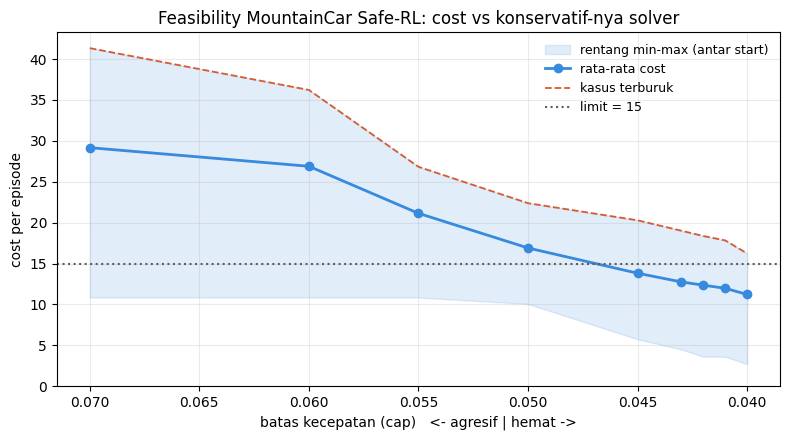

In [8]:
caps_arr = np.array([x['cap'] for x in rows])
cmean = np.array([x['cmean'] for x in rows])
cmin  = np.array([x['cmin']  for x in rows])
cmax  = np.array([x['cmax']  for x in rows])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(caps_arr, cmin, cmax, color='#378ADD', alpha=0.15, label='rentang min-max (antar start)')
ax.plot(caps_arr, cmean, '-o', color='#378ADD', lw=2, label='rata-rata cost')
ax.plot(caps_arr, cmax, '--', color='#D85A30', lw=1.3, label='kasus terburuk')
ax.axhline(COST_LIMIT, color='#5F5E5A', lw=1.5, ls=':', label=f'limit = {COST_LIMIT:.0f}')

ax.invert_xaxis()  # kiri = agresif/cepat, kanan = hemat/lambat
ax.set_xlabel('batas kecepatan (cap)   <- agresif | hemat ->')
ax.set_ylabel('cost per episode')
ax.set_title('Feasibility MountainCar Safe-RL: cost vs konservatif-nya solver')
ax.set_ylim(0, None)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig('cost_vs_speed_cap.png', dpi=130, bbox_inches='tight')
plt.show()

## Kesimpulan

- **Feasible, tapi tipis.** Solver paling hemat (cap = 0.040) mencapai rata-rata cost ~11 — di bawah limit 15. Jadi daerah aman ada.
- **Ngebut biasa ~29** — hampir 2x limit. Untuk lolos, agen harus sengaja konservatif (lebih banyak langkah → reward lebih rendah).
- **Tidak 100% aman di semua start.** Bahkan di cap terketat, kolom max masih ~16 dan cuma ~57% episode yang cost-nya <= 15.

Implikasi: jalankan Tahap 2, tapi ekspektasi return realistis (ada pengorbanan), dan kalau cost mentok ~16-18 tanpa bisa turun tanpa merusak solve, longgarkan `cost_limit` ke ~18-20.